# MD Simulation Tutorial: Lysozyme from Scratch

**What you'll do in ~45 minutes:**
1. Download a protein structure from PDB
2. Fix it for simulation (add hydrogens, remove crystal artifacts)
3. Put it in a water box with salt ions
4. Minimize energy (remove atomic clashes)
5. Equilibrate (heat up, stabilize pressure)
6. Run 2 ns of production MD
7. Analyze: RMSD, RMSF, H-bonds, contacts

**Runtime:** Set to GPU (Runtime → Change runtime type → T4 GPU)

---

## 0. Install Packages (~3 min)

In [1]:
!pip install -q condacolab
import condacolab
condacolab.install()


📢 Announcement 📢
condacolab==0.2 will be released soon! Try it with:

    !pip install -q https://github.com/conda-incubator/condacolab/archive/main.zip
    import condacolab
    condacolab.install()

0.2.x introduces a new installation method based on Pixi, with customizable Python versions.
This may be breaking for your workflow. If that's the case, please report it at
https://github.com/conda-incubator/condacolab and pin your `pip install` command to
condacolab==0.1 as a workaround.

✨🍰✨ Everything looks OK!


In [2]:
# After condacolab installs, the runtime restarts. Run this cell next.
import condacolab
condacolab.check()

!mamba install -y -c conda-forge openmm pdbfixer mdanalysis mdtraj matplotlib numpy

✨🍰✨ Everything looks OK!
[+] 0.0s
[+] 0.1s
conda-forge/linux-64  ⣾  
conda-forge/noarch     2%[+] 0.2s
conda-forge/linux-64   7%
conda-forge/noarch    19%[+] 0.3s
conda-forge/linux-64  14%
conda-forge/noarch    34%[+] 0.4s
conda-forge/linux-64  20%
conda-forge/noarch    47%[+] 0.5s
conda-forge/linux-64  26%
conda-forge/noarch    58%[+] 0.6s
conda-forge/linux-64  31%
conda-forge/noarch    69%[+] 0.7s
conda-forge/linux-64  35%
conda-forge/noarch    77%[+] 0.8s
conda-forge/linux-64  38%
conda-forge/noarch    88%[+] 0.9s
conda-forge/linux-64  43%
conda-forge/noarch    93%conda-forge/noarch                                
[+] 1.0s
conda-forge/linux-64  49%[+] 1.1s
conda-forge/linux-64  56%[+] 1.2s
conda-forge/linux-64  64%[+] 1.3s
conda-forge/linux-64  67%[+] 1.4s
conda-forge/linux-64  74%[+] 1.5s
conda-forge/linux-64  77%[+] 1.6s
conda-forge/linux-64  79%[+] 1.7s
conda-forge/linux-64  79%[+] 1.8s
conda-forge/linux-64  79%[+] 1.9s
conda-forge/linux-64  79%[+] 2.0s
conda-forge/linux-64  79%[

In [3]:
# Verify installation
import openmm
print(f"OpenMM version: {openmm.__version__}")
print(f"Platforms: {[openmm.Platform.getPlatform(i).getName() for i in range(openmm.Platform.getNumPlatforms())]}")

# Check for GPU
try:
    p = openmm.Platform.getPlatformByName('CUDA')
    print(f"GPU available! Using CUDA.")
except:
    print("No GPU — simulation will be slower but still works.")

OpenMM version: 8.6.1
Platforms: ['Reference', 'CPU', 'CUDA', 'OpenCL']
GPU available! Using CUDA.


---
## 1. Fetch and Fix the Protein Structure

**Protein:** Lysozyme (PDB ID: 1AKI) — 129 residues, very stable, the classic MD tutorial system.

**Why fix it?** X-ray crystallography structures have:
- Missing hydrogens (X-ray can't see them)
- Crystal waters/ions (not part of the biology)
- Sometimes missing loops or non-standard residues

PDBFixer handles all of this.

In [4]:
from pdbfixer import PDBFixer
from openmm.app import PDBFile
import os

os.makedirs("output/plots", exist_ok=True)

# Download directly from RCSB PDB
fixer = PDBFixer(pdbid='1AKI')

n_atoms_raw = sum(1 for a in fixer.topology.atoms())
print(f"Raw structure: {n_atoms_raw} atoms, "
      f"{sum(1 for r in fixer.topology.residues())} residues, "
      f"{sum(1 for c in fixer.topology.chains())} chain(s)")

# Fix everything
fixer.findMissingResidues()
fixer.findNonstandardResidues()
fixer.replaceNonstandardResidues()
fixer.removeHeterogens(keepWater=False)  # Remove crystal waters + ions
fixer.findMissingAtoms()
fixer.addMissingAtoms()
fixer.addMissingHydrogens(pH=7.0)        # Add H atoms at physiological pH

n_atoms_fixed = sum(1 for a in fixer.topology.atoms())
print(f"Fixed structure: {n_atoms_fixed} atoms (added ~{n_atoms_fixed - n_atoms_raw} hydrogens)")

# Save
with open("output/1AKI_fixed.pdb", 'w') as f:
    PDBFile.writeFile(fixer.topology, fixer.positions, f)
print("Saved: output/1AKI_fixed.pdb")

Raw structure: 1079 atoms, 207 residues, 2 chain(s)
Fixed structure: 1960 atoms (added ~881 hydrogens)
Saved: output/1AKI_fixed.pdb


---
## 2. Solvate and Energy Minimize

**Force field:** Amber14-SB — tells OpenMM how atoms interact (bonds, angles, charges).

**Solvation:** Put the protein in a box of TIP3P-FB water with 150 mM NaCl (physiological salt).

**Minimization:** Relax atomic clashes. Without this, the simulation would explode on step 1.

In [5]:
from openmm.app import ForceField, Modeller, PME, HBonds, Simulation, PDBFile
from openmm import LangevinMiddleIntegrator, unit, Platform

pdb = PDBFile("output/1AKI_fixed.pdb")
forcefield = ForceField('amber14-all.xml', 'amber14/tip3pfb.xml')

# Add water box (1.0 nm padding) + 150 mM NaCl
modeller = Modeller(pdb.topology, pdb.positions)
modeller.addSolvent(
    forcefield,
    model='tip3p',
    padding=1.0 * unit.nanometers,
    ionicStrength=0.15 * unit.molar
)

n_total = sum(1 for a in modeller.topology.atoms())
n_water = sum(1 for r in modeller.topology.residues() if r.name == 'HOH')
print(f"Total atoms: {n_total}")
print(f"Water molecules: {n_water}")
print(f"Ions: {[r.name for r in modeller.topology.residues() if r.name in ('NA','CL')]}")

# Create system
system = forcefield.createSystem(
    modeller.topology,
    nonbondedMethod=PME,        # Efficient long-range electrostatics
    nonbondedCutoff=1.0 * unit.nanometers,
    constraints=HBonds          # Constrain H-bonds → 2 fs timestep
)

integrator = LangevinMiddleIntegrator(
    300 * unit.kelvin,           # Room temperature
    1.0 / unit.picoseconds,      # Friction
    0.002 * unit.picoseconds     # 2 fs timestep
)

# Pick fastest platform
try:
    platform = Platform.getPlatformByName('CUDA')
    pname = 'CUDA'
except:
    platform = Platform.getPlatformByName('CPU')
    pname = 'CPU'
print(f"Platform: {pname}")

simulation = Simulation(modeller.topology, system, integrator, platform)
simulation.context.setPositions(modeller.positions)

# Minimize
state = simulation.context.getState(getEnergy=True)
print(f"\nEnergy BEFORE minimization: {state.getPotentialEnergy()}")

print("Minimizing...")
simulation.minimizeEnergy(maxIterations=1000)

state = simulation.context.getState(getEnergy=True, getPositions=True)
print(f"Energy AFTER minimization:  {state.getPotentialEnergy()}")

with open("output/1AKI_minimized.pdb", 'w') as f:
    PDBFile.writeFile(simulation.topology, state.getPositions(), f)
print("\nSaved: output/1AKI_minimized.pdb")

Total atoms: 20533
Water molecules: 6177
Ions: ['NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'CL', 'CL', 'CL', 'CL', 'CL', 'CL', 'CL', 'CL', 'CL', 'CL', 'CL', 'CL', 'CL', 'CL', 'CL', 'CL', 'CL', 'CL', 'CL', 'CL', 'CL', 'CL', 'CL', 'CL', 'CL']
Platform: CUDA

Energy BEFORE minimization: -218045.8315532289 kJ/mol
Minimizing...
Energy AFTER minimization:  -382007.9087016664 kJ/mol

Saved: output/1AKI_minimized.pdb


---
## 3. Equilibration: NVT (100 ps) then NPT (100 ps)

**NVT** (constant Volume, Temperature): Heat to 300 K, let water settle.  
**NPT** (constant Pressure, Temperature): Allow box to resize, density → 1.0 g/cm³.

Only after both is the system ready for production.

In [6]:
from openmm.app import StateDataReporter, DCDReporter
from openmm import MonteCarloBarostat
import sys

# === NVT: 100 ps ===
print("=" * 50)
print("NVT Equilibration (100 ps) — stabilize temperature")
print("=" * 50)

pdb = PDBFile("output/1AKI_minimized.pdb")
forcefield = ForceField('amber14-all.xml', 'amber14/tip3pfb.xml')
system = forcefield.createSystem(
    pdb.topology, nonbondedMethod=PME,
    nonbondedCutoff=1.0*unit.nanometers, constraints=HBonds
)
integrator = LangevinMiddleIntegrator(300*unit.kelvin, 1.0/unit.picoseconds, 0.002*unit.picoseconds)

try:
    platform = Platform.getPlatformByName('CUDA')
except:
    platform = Platform.getPlatformByName('CPU')

sim = Simulation(pdb.topology, system, integrator, platform)
sim.context.setPositions(pdb.positions)
sim.context.setVelocitiesToTemperature(300 * unit.kelvin)

sim.reporters.append(StateDataReporter(
    "output/nvt_log.csv", 1000, step=True, time=True,
    temperature=True, potentialEnergy=True, separator=","
))
sim.reporters.append(StateDataReporter(
    sys.stdout, 10000, step=True, time=True, temperature=True,
    speed=True, remainingTime=True, totalSteps=50000
))

sim.step(50000)  # 100 ps
sim.saveCheckpoint("output/nvt.chk")
print("\nNVT complete. Checkpoint saved.")

NVT Equilibration (100 ps) — stabilize temperature
#"Step","Time (ps)","Temperature (K)","Speed (ns/day)","Time Remaining"
10000,19.999999999999794,302.41210034214095,0,--
20000,40.00000000000292,299.1973799085116,363,0:14
30000,60.00000000002736,297.97601554983885,361,0:09
40000,79.99999999999496,300.19556426040424,357,0:04
50000,99.99999999994834,300.40850132916694,355,0:00

NVT complete. Checkpoint saved.


In [7]:
# === NPT: 100 ps ===
print("=" * 50)
print("NPT Equilibration (100 ps) — stabilize density")
print("=" * 50)

# Add barostat (pressure control)
system.addForce(MonteCarloBarostat(1.0*unit.atmospheres, 300*unit.kelvin, 25))

integrator2 = LangevinMiddleIntegrator(300*unit.kelvin, 1.0/unit.picoseconds, 0.002*unit.picoseconds)
sim2 = Simulation(pdb.topology, system, integrator2, platform)
sim2.loadCheckpoint("output/nvt.chk")

sim2.reporters.append(StateDataReporter(
    "output/npt_log.csv", 1000, step=True, time=True,
    temperature=True, density=True, potentialEnergy=True, separator=","
))
sim2.reporters.append(StateDataReporter(
    sys.stdout, 10000, step=True, time=True, temperature=True,
    density=True, speed=True, remainingTime=True, totalSteps=50000
))

sim2.step(50000)  # 100 ps

state = sim2.context.getState(getPositions=True)
with open("output/1AKI_equilibrated.pdb", 'w') as f:
    PDBFile.writeFile(sim2.topology, state.getPositions(), f)
sim2.saveCheckpoint("output/npt.chk")
print("\nNPT complete. Equilibrated structure saved.")

NPT Equilibration (100 ps) — stabilize density
#"Step","Time (ps)","Temperature (K)","Density (g/mL)","Speed (ns/day)","Time Remaining"
60000,119.99999999990173,303.09607866509,1.018524238830936,0,--
70000,139.99999999994037,303.8701903794383,1.033193044647693,297,23:59:49
80000,160.00000000003587,299.7170472235691,1.0331447766114366,295,23:59:43
90000,180.00000000013137,301.2538896100243,1.0334612468373001,293,23:59:37
100000,200.00000000022686,299.74007709728147,1.0398050265619996,293,23:59:31

NPT complete. Equilibrated structure saved.


### Check equilibration: plot temperature and density

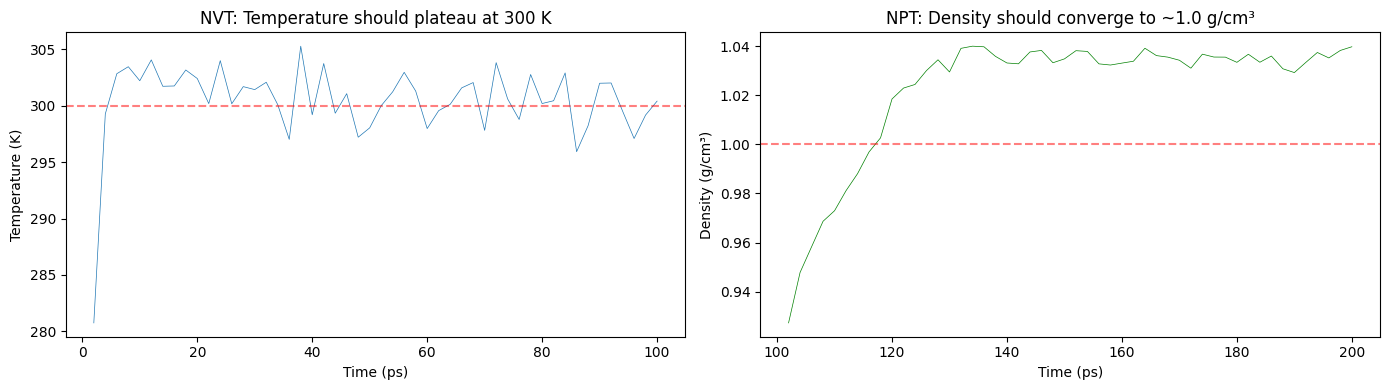

If both look stable, equilibration worked. Proceed to production.


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# NVT temperature
nvt = pd.read_csv("output/nvt_log.csv")
temp_col = [c for c in nvt.columns if 'temp' in c.lower()][0]
time_col = [c for c in nvt.columns if 'time' in c.lower()][0]
axes[0].plot(nvt[time_col], nvt[temp_col], linewidth=0.5)
axes[0].axhline(300, color='red', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Time (ps)')
axes[0].set_ylabel('Temperature (K)')
axes[0].set_title('NVT: Temperature should plateau at 300 K')

# NPT density
npt = pd.read_csv("output/npt_log.csv")
dens_col = [c for c in npt.columns if 'dens' in c.lower()][0]
time_col2 = [c for c in npt.columns if 'time' in c.lower()][0]
axes[1].plot(npt[time_col2], npt[dens_col], linewidth=0.5, color='green')
axes[1].axhline(1.0, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Time (ps)')
axes[1].set_ylabel('Density (g/cm³)')
axes[1].set_title('NPT: Density should converge to ~1.0 g/cm³')

plt.tight_layout()
plt.savefig("output/plots/equilibration.png", dpi=150)
plt.show()
print("If both look stable, equilibration worked. Proceed to production.")

---
## 4. Production MD (2 ns)

NOW we collect data. Everything before was preparation.

We save a "frame" (snapshot of all atom positions) every 10 ps.  
2 ns / 10 ps = 200 frames in the trajectory.

On Colab T4 GPU: ~5-10 minutes. On CPU: ~30-60 minutes.  
Change `PRODUCTION_STEPS` to `5_000_000` for 10 ns if you have time.

In [9]:
from openmm.app import CheckpointReporter
import time as timer

# ======= CONFIGURE =======
PRODUCTION_STEPS = 1_000_000   # 2 ns (change to 5_000_000 for 10 ns)
SAVE_INTERVAL = 5000           # Save frame every 10 ps
# =========================

total_ns = PRODUCTION_STEPS * 0.002 / 1000
n_frames = PRODUCTION_STEPS // SAVE_INTERVAL
print(f"Production: {total_ns} ns, saving {n_frames} frames")

# Rebuild with barostat
pdb_eq = PDBFile("output/1AKI_equilibrated.pdb")
system3 = forcefield.createSystem(
    pdb_eq.topology, nonbondedMethod=PME,
    nonbondedCutoff=1.0*unit.nanometers, constraints=HBonds
)
system3.addForce(MonteCarloBarostat(1.0*unit.atmospheres, 300*unit.kelvin, 25))

integrator3 = LangevinMiddleIntegrator(300*unit.kelvin, 1.0/unit.picoseconds, 0.002*unit.picoseconds)
sim3 = Simulation(pdb_eq.topology, system3, integrator3, platform)
sim3.loadCheckpoint("output/npt.chk")

# Save trajectory (DCD format — compact binary)
sim3.reporters.append(DCDReporter("output/trajectory.dcd", SAVE_INTERVAL))
sim3.reporters.append(StateDataReporter(
    "output/production_log.csv", SAVE_INTERVAL, step=True, time=True,
    potentialEnergy=True, temperature=True, density=True, speed=True, separator=","
))
sim3.reporters.append(StateDataReporter(
    sys.stdout, 50000, step=True, time=True, temperature=True,
    speed=True, remainingTime=True, totalSteps=PRODUCTION_STEPS
))
sim3.reporters.append(CheckpointReporter("output/production.chk", 50000))

t0 = timer.time()
sim3.step(PRODUCTION_STEPS)
elapsed = timer.time() - t0

# Save final structure
state = sim3.context.getState(getPositions=True)
with open("output/1AKI_final.pdb", 'w') as f:
    PDBFile.writeFile(sim3.topology, state.getPositions(), f)

print(f"\nDone! {total_ns} ns in {elapsed/60:.1f} minutes")
print(f"Speed: {total_ns / (elapsed/86400):.0f} ns/day")
print(f"Trajectory: output/trajectory.dcd ({n_frames} frames)")

Production: 2.0 ns, saving 200 frames
#"Step","Time (ps)","Temperature (K)","Speed (ns/day)","Time Remaining"
150000,300.00000000070435,304.7284325432979,0,--
200000,400.00000000118183,294.57855128304044,274,8:24
250000,500.0000000016593,300.51432270624446,269,8:01
300000,599.9999999996356,301.0100452010565,269,7:30
350000,699.999999997271,300.7793894116274,269,6:58
400000,799.9999999949063,297.7584144853339,268,6:26
450000,899.9999999925416,300.06722627230374,268,5:54
500000,999.9999999901769,301.22034900906533,268,5:22
550000,1099.9999999878123,302.4266279078258,268,4:50
600000,1199.9999999854476,301.12276215078623,268,4:18
650000,1299.999999983083,301.715982240801,268,3:45
700000,1399.9999999807183,296.6682891647447,268,3:13
750000,1499.9999999783536,298.65555303473667,268,2:41
800000,1599.9999999759889,297.6394044887177,268,2:09
850000,1699.9999999736242,301.020087297152,268,1:36
900000,1799.9999999712595,298.6005000323642,268,1:04
950000,1899.9999999688948,302.0980505235811,268,0:

---
## 5. Analysis with MDAnalysis

**This is the skill you need for your PPI platform.**

Everything above was setup. The code below — loading trajectories, selecting atoms, computing per-residue per-frame properties — is what your platform's analysis engine will do at its core.

### 5.1 Load the trajectory

In [10]:
import MDAnalysis as mda
from MDAnalysis.analysis import rms, align
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load: PDB = topology (what atoms exist), DCD = trajectory (where they are)
u = mda.Universe("output/1AKI_equilibrated.pdb", "output/trajectory.dcd")

print(f"Atoms:    {u.atoms.n_atoms}")
print(f"Residues: {u.residues.n_residues}")
print(f"Frames:   {u.trajectory.n_frames}")
print(f"Timestep: {u.trajectory.dt} ps")
print(f"Total:    {u.trajectory.n_frames * u.trajectory.dt / 1000:.1f} ns")

Atoms:    20533
Residues: 6348
Frames:   200
Timestep: 10.000000029814057 ps
Total:    2.0 ns


### 5.2 Atom selections

MDAnalysis uses a selection language (like SQL for atoms). Master this — you'll use it constantly.

```python
u.select_atoms("protein")              # all protein atoms
u.select_atoms("name CA")              # alpha carbons (1 per residue)
u.select_atoms("protein and backbone") # N, CA, C, O of each residue
u.select_atoms("resid 50:60")          # residues 50-60
u.select_atoms("around 5.0 resid 50")  # atoms within 5 Å of residue 50
```

For your PPI platform:
```python
chain_A = u.select_atoms("segid A")    # first protein
chain_B = u.select_atoms("segid B")    # second protein
interface = u.select_atoms("segid A and around 5.0 segid B")  # A's interface
```

In [11]:
protein = u.select_atoms("protein")
ca_atoms = u.select_atoms("protein and name CA")
backbone = u.select_atoms("protein and backbone")

print(f"Protein: {protein.n_atoms} atoms")
print(f"Cα:      {ca_atoms.n_atoms} atoms (one per residue)")
print(f"Backbone: {backbone.n_atoms} atoms")

Protein: 1960 atoms
Cα:      129 atoms (one per residue)
Backbone: 516 atoms


### 5.3 RMSD — How much did the protein move?

RMSD = Root Mean Square Deviation from the starting structure.  
Low RMSD (~0.1 nm) = stable. Rising RMSD = conformational change. Plateau = equilibrated.

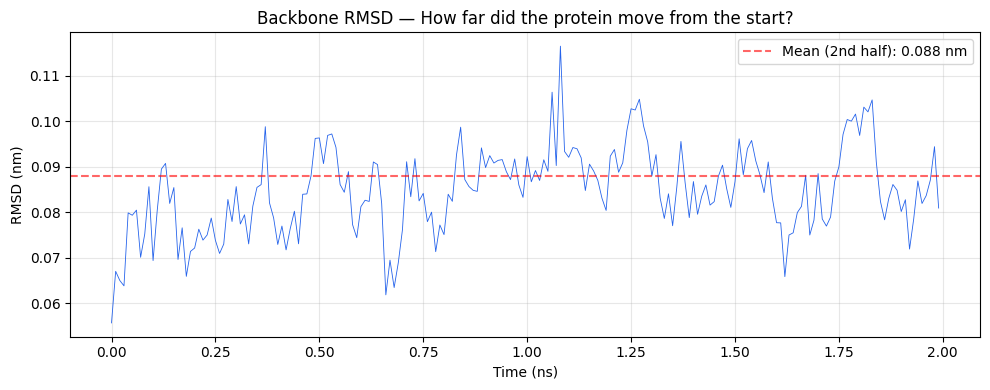

Mean RMSD (2nd half): 0.088 nm
Lysozyme typically: 0.10–0.15 nm (very stable)


In [12]:
# Align all frames to reference (MANDATORY before RMSD)
ref = mda.Universe("output/1AKI_equilibrated.pdb")
align.AlignTraj(u, ref, select="protein and name CA", in_memory=True).run()

# Compute backbone RMSD
R = rms.RMSD(u, ref, select="backbone")
R.run()

time_ns = R.results.rmsd[:, 1] / 1000  # ps → ns
rmsd_nm = R.results.rmsd[:, 2] / 10    # Å → nm

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(time_ns, rmsd_nm, lw=0.6, color='#2563eb')
mean_rmsd = np.mean(rmsd_nm[len(rmsd_nm)//2:])
ax.axhline(mean_rmsd, color='red', ls='--', alpha=0.6, label=f'Mean (2nd half): {mean_rmsd:.3f} nm')
ax.set_xlabel('Time (ns)'); ax.set_ylabel('RMSD (nm)')
ax.set_title('Backbone RMSD — How far did the protein move from the start?')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('output/plots/rmsd.png', dpi=150); plt.show()

print(f"Mean RMSD (2nd half): {mean_rmsd:.3f} nm")
print("Lysozyme typically: 0.10–0.15 nm (very stable)")

### 5.4 RMSF — Which residues are flexible?

RMSF = per-residue average fluctuation. High RMSF = flexible loop. Low RMSF = rigid helix/sheet.

**For your PPI platform:** Interface residues with high RMSF = dynamic binding hotspots. This is EXACTLY what the rigid lock-and-key model misses.

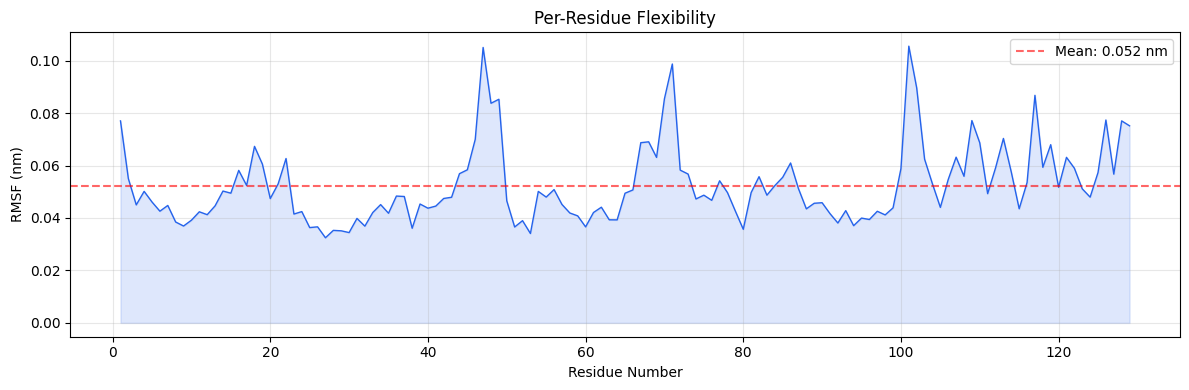

Most flexible residues:
  ASP 101: 0.105 nm
  THR 47: 0.105 nm
  GLY 71: 0.099 nm
  GLY 102: 0.090 nm
  GLY 117: 0.087 nm


In [13]:
rmsf_analysis = rms.RMSF(ca_atoms)
rmsf_analysis.run()

rmsf_nm = rmsf_analysis.results.rmsf / 10  # Å → nm
resids = ca_atoms.resids

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(resids, rmsf_nm, lw=1.0, color='#2563eb')
ax.fill_between(resids, rmsf_nm, alpha=0.15, color='#2563eb')
ax.axhline(np.mean(rmsf_nm), color='red', ls='--', alpha=0.6, label=f'Mean: {np.mean(rmsf_nm):.3f} nm')
ax.set_xlabel('Residue Number'); ax.set_ylabel('RMSF (nm)')
ax.set_title('Per-Residue Flexibility')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('output/plots/rmsf.png', dpi=150); plt.show()

# Top 5 flexible residues
top5 = np.argsort(rmsf_nm)[-5:][::-1]
print("Most flexible residues:")
for i in top5:
    print(f"  {ca_atoms[i].resname} {ca_atoms[i].resid}: {rmsf_nm[i]:.3f} nm")

### 5.5 Radius of Gyration — Is the protein staying compact?

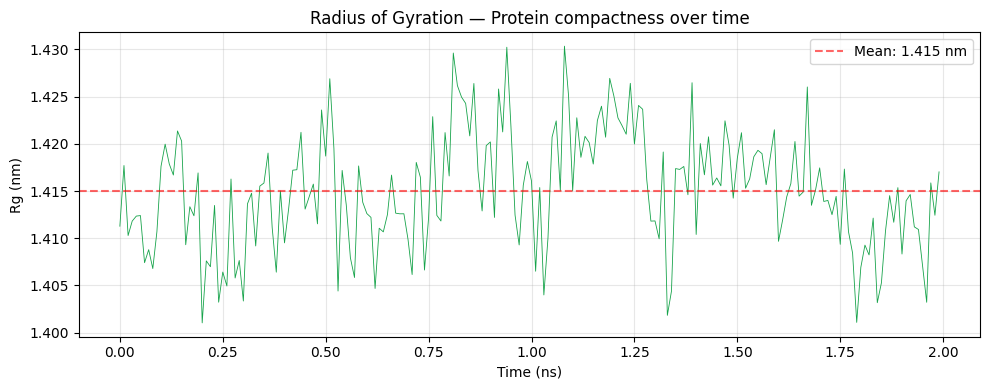

Mean Rg: 1.415 ± 0.006 nm


In [14]:
rgyr = []
for ts in u.trajectory:
    rgyr.append(protein.radius_of_gyration() / 10)  # Å → nm
rgyr = np.array(rgyr)
time_rg = np.arange(len(rgyr)) * u.trajectory.dt / 1000

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(time_rg, rgyr, lw=0.6, color='#16a34a')
ax.axhline(np.mean(rgyr), color='red', ls='--', alpha=0.6, label=f'Mean: {np.mean(rgyr):.3f} nm')
ax.set_xlabel('Time (ns)'); ax.set_ylabel('Rg (nm)')
ax.set_title('Radius of Gyration — Protein compactness over time')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('output/plots/rgyr.png', dpi=150); plt.show()
print(f"Mean Rg: {np.mean(rgyr):.3f} ± {np.std(rgyr):.3f} nm")

### 5.6 Hydrogen Bonds

**For your PPI platform:** H-bonds between two chains = intermolecular H-bonds.  
Their occupancy (% of frames present) = how stable each interface contact is.

In [15]:
hbonds = HydrogenBondAnalysis(
    u, donors_sel="protein", hydrogens_sel="protein", acceptors_sel="protein",
    d_a_cutoff=3.5, d_h_a_angle_cutoff=150
)
hbonds.run()

counts = hbonds.count_by_time()
time_hb = counts[:, 0] / 1000

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(time_hb, counts[:, 1], lw=0.6, color='#dc2626')
ax.axhline(np.mean(counts[:, 1]), color='black', ls='--', alpha=0.6,
           label=f'Mean: {np.mean(counts[:, 1]):.0f}')
ax.set_xlabel('Time (ns)'); ax.set_ylabel('H-bonds')
ax.set_title('Intra-protein Hydrogen Bonds Over Time')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('output/plots/hbonds.png', dpi=150); plt.show()
print(f"Average H-bonds per frame: {np.mean(counts[:, 1]):.0f}")

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

### 5.7 Contact Map — Which residues are near each other?

**This is YOUR core analysis for PPIs.**
- Contact frequency >80% = stable interface
- 20–80% = dynamic/transient
- <20% = rare encounter

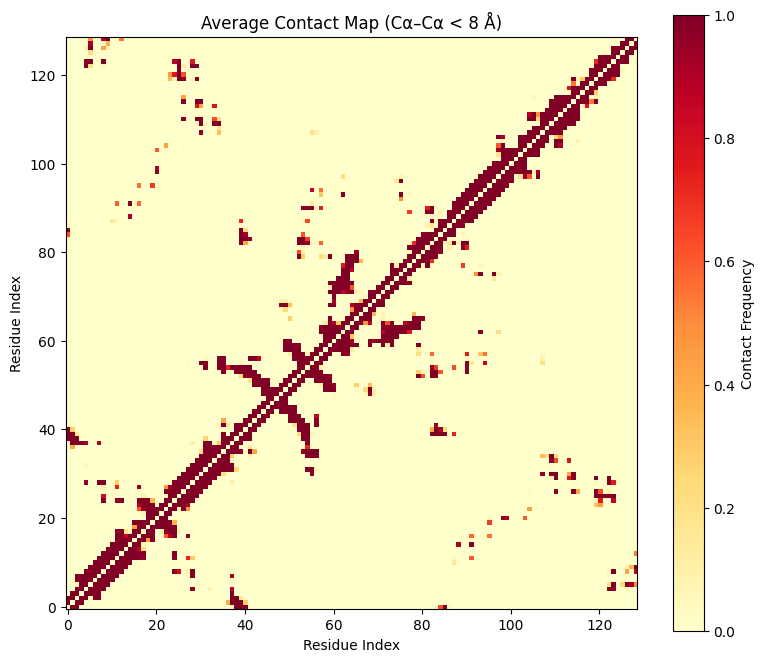

In [16]:
n_res = ca_atoms.n_atoms
contact_map = np.zeros((n_res, n_res))

for ts in u.trajectory:
    pos = ca_atoms.positions
    for i in range(n_res):
        diff = pos[i+1:] - pos[i]
        dists = np.sqrt(np.sum(diff**2, axis=1))
        contact_map[i, i+1:] += (dists < 8.0)  # Cα–Cα < 8 Å
        contact_map[i+1:, i] += (dists < 8.0)

contact_map /= u.trajectory.n_frames  # Normalize to frequency (0–1)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(contact_map, cmap='YlOrRd', vmin=0, vmax=1, origin='lower')
ax.set_xlabel('Residue Index'); ax.set_ylabel('Residue Index')
ax.set_title('Average Contact Map (Cα–Cα < 8 Å)')
plt.colorbar(im, ax=ax, label='Contact Frequency', shrink=0.8)
plt.tight_layout(); plt.savefig('output/plots/contact_map.png', dpi=150); plt.show()

---
## Summary

You now know how to:
1. **Fetch + fix** a protein structure (PDBFixer)
2. **Solvate** it in water + ions (OpenMM Modeller)
3. **Minimize** energy (remove clashes)
4. **Equilibrate** (NVT → NPT)
5. **Run production** MD and save a trajectory
6. **Analyze** with MDAnalysis: RMSD, RMSF, Rg, H-bonds, contacts

### For your PPI platform, the jump from here is:
- Load a **two-chain complex** (e.g., barnase–barstar, PDB 1BRS) instead of one protein
- Compute **inter-chain** contacts, H-bonds, SASA
- Track contact **occupancy across replicas** (3 independent runs)
- That's your core analysis engine.

### Next step:
Run this exact pipeline on **1BRS** (barnase–barstar complex). That's your first PPI system.